# Data Preprocessing and EDA Pipeline


### Imports and Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA




### Load Dataset


In [2]:
df = pd.read_csv("../data/data.csv")
df.head()


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


### Dataset Inspection and Summary


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget Class (position) Distribution:")
print(df['position'].value_counts())
print("\nSummary:")
print(df.describe())


Shape: (54600, 75)

Columns:
Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'spri

                age  jersey_number     height_cm     weight_kg  \
count  54600.000000   54600.000000  54600.000000  54600.000000   
mean      26.296484      13.500000    181.654341     75.754853   
std        4.067519       7.500069      6.277792      3.951481   
min       17.000000       1.000000    163.000000     65.000000   
25%       23.000000       7.000000    177.000000     73.000000   
50%       26.000000      13.500000    182.000000     76.000000   
75%       29.000000      20.000000    186.000000     78.000000   
max       39.000000      26.000000    200.000000     87.000000   

       market_value_eur    goals_team  goals_opponent  minutes_played  \
count      5.460000e+04  54600.000000    54600.000000    54600.000000   
mean       2.008445e+07      1.330476        1.330476       36.199817   
std        2.718866e+07      1.147814        1.147814       36.419755   
min        5.288220e+05      0.000000        0.000000        0.000000   
25%        4.444778e+06      0.000000   

### EDA Observation
The dataset contains demographic and performance metrics along with the target position. Missing values, duplicates, and target distributions are audited prior to modeling.


### Data Cleaning


In [4]:
df = df[df['minutes_played'] > 0].reset_index(drop=True)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates and zero-minute entries:", df.shape)


Shape after removing duplicates and zero-minute entries: (31558, 75)


### Exploratory Data Visualizations


C:\Users\Rohith\AppData\Local\Temp\ipykernel_41776\3063447421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='position', order=['Defender', 'Midfielder', 'Forward', 'Goalkeeper'], palette='Set2')


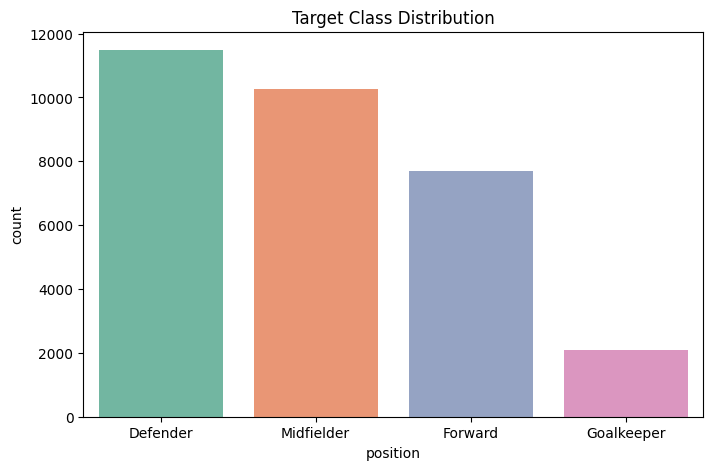

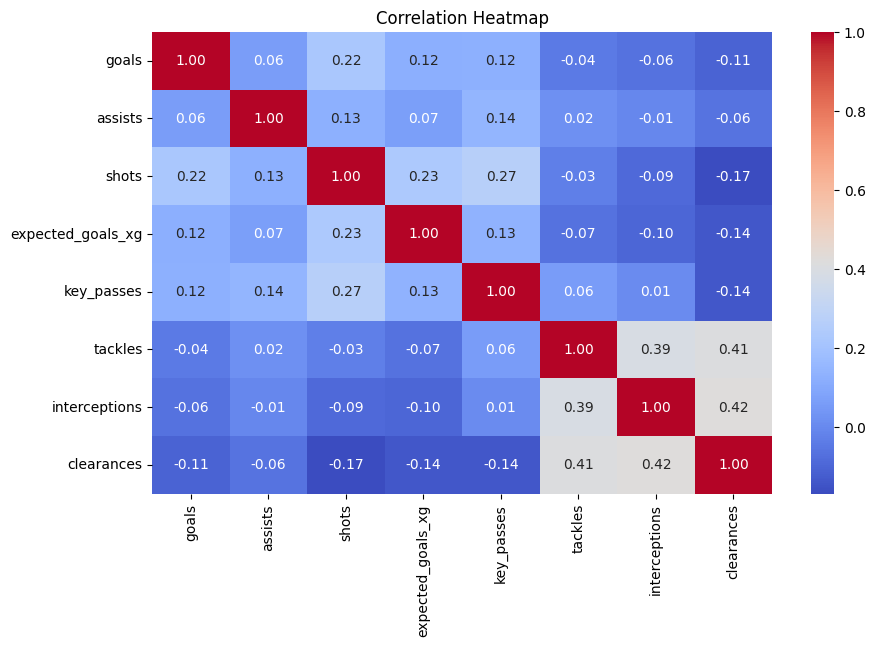

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='position', order=['Defender', 'Midfielder', 'Forward', 'Goalkeeper'], palette='Set2')
plt.title("Target Class Distribution")
plt.show()

plt.figure(figsize=(10, 6))
core_cols = ['goals', 'assists', 'shots', 'expected_goals_xg', 'key_passes', 'tackles', 'interceptions', 'clearances']
sns.heatmap(df[core_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### Feature Engineering


In [6]:
#Calculates the player's goals + assists contribution per 90 minutes
df['goal_contribution_rate'] = (df['goals'] + df['assists']) / (df['minutes_played'] / 90.0 + 1e-5)
#Combines total distance and sprint distance to measure the player's work-rate intensity
df['work_rate_intensity'] = df['distance_covered_km'] + (df['sprint_distance_km'] * 1.5)
#Combines key passes and pass accuracy to measure the player's passing efficiency
df['passing_efficiency'] = (df['key_passes'] + 1) * (df['pass_accuracy'] / 100.0)

print("Engineering complete. Missing values count:", df.isnull().sum().sum())


Engineering complete. Missing values count: 0


### Encoding, Splitting, and Feature Scaling


In [7]:
le = LabelEncoder()
df['position_encoded'] = le.fit_transform(df['position'])

df = pd.get_dummies(df, columns=['preferred_foot'], drop_first=True)

feature_cols = [
    'age', 'height_cm', 'weight_kg', 'minutes_played', 'goals', 'assists',
    'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
    'key_passes', 'pass_accuracy', 'tackles', 'interceptions', 'clearances',
    'blocks', 'recoveries', 'fouls_committed', 'distance_covered_km',
    'sprint_distance_km', 'top_speed_kmh', 'stamina_score', 'possession_impact',
    'creativity_score', 'consistency_score', 'pressure_resistance',
    'goal_contribution_rate', 'work_rate_intensity', 'passing_efficiency',
    'preferred_foot_Right'
]

X = df[feature_cols]
y = df['position_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (25246, 30) Test shape: (6312, 30)


### Principal Component Analysis (PCA)


In [8]:
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA Train shape:", X_train_pca.shape)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


PCA Train shape: (25246, 10)
Explained Variance Ratio: [0.19081772 0.12264385 0.0756359  0.05698849 0.05359559 0.04717893
 0.03911871 0.03396979 0.0329028  0.03150452]


### Export Preprocessed Data


In [9]:
df.to_csv('../data/df_preprocessed_classification.csv', index=False)
df.to_csv('../data/df_preprocessed_regression.csv', index=False)
print('Preprocessed classification and regression datasets saved successfully.')


Preprocessed classification and regression datasets saved successfully.
